# Eddy properties and measured tilt
Surface properties, depth-dependent structure, profile summaries, core stratification and cached vertical velocity. Major-axis orientation is intentionally left to its existing notebook. All data remain paired by **Eddy and Day**; maxima are within that day's sampled column, not the entire lifetime.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
HERE=Path.cwd().resolve()
ANALYSIS=next((p for p in (HERE,*HERE.parents) if (p/'seacofs_tilt_tools.py').exists()),None)
if ANALYSIS is None: raise FileNotFoundError('Launch inside seacofs_eddy_tilt_analysis')
WORK=ANALYSIS/'eddy_env_tilt_controls'
for p in (ANALYSIS,WORK,ANALYSIS/'tilt_mechanisms'):
    if str(p) not in sys.path: sys.path.insert(0,str(p))
import seacofs_tilt_tools as tilt
import control_tools as ctl
import mechanism_tools as mech
N_BOOT=300
MIN_EDDIES_PER_BIN=10
MAX_DEPTH_M=1000
TARGET_DEPTHS=[0,100,200,500,1000]
DEPTH_TOLERANCE_M=65
MIN_N2_COVERAGE=.8
SAVE_RESULTS=True
paths=tilt.Paths()
OUTPUT_ROOT=Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/eddy_env_tilt_controls')
N2_CACHE=mech.DEFAULT_N2_CACHE_PATH
VV_CACHE=Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/vertical_velocity_climatology/core_vertical_velocity_upper_1000m.parquet')
VV_FRACTION=1.5
MIN_VV_CELLS=8
MIN_VV_COVERAGE=.7
results={}
inputs=[paths.eddies,paths.tilt,paths.vert,paths.grid,paths.z_r,WORK/'control_tools.py']

In [2]:
grid=tilt.load_grid(paths.grid,paths.z_r)
raw,_=tilt.load_tilt_tables(paths,add_regions=True,grid=grid)
surface=ctl.prepare_surface(raw,grid)
vertical=ctl.prepare_profiles(tilt.load_vert(paths),surface,MAX_DEPTH_M)
summary=ctl.profile_summaries(vertical)
surface=ctl.merge(surface,summary)
print('Surface rows:',len(surface),'Eddies:',surface.Eddy.nunique())
print('Rows with profiles:',surface.vertical_extent_m.notna().sum())
print('Measured TiltDis/TiltDir are loaded, never recomputed.')

Surface rows: 127426 Eddies: 2982
Rows with profiles: 120543
Measured TiltDis/TiltDir are loaded, never recomputed.


In [3]:
# vertical = tilt.load_vert(paths)
# from scipy.spatial.distance import pdist
# spread = (vertical.groupby(['Eddy','Day'])
#           .apply(lambda x: pdist(x[['xc','yc']].dropna()).max()
#                  if x[['xc','yc']].dropna().shape[0] > 1 else np.nan)
#           .rename('TiltMaxSpread').reset_index())

# surface = surface.merge(spread, on=['Eddy','Day'], how='left')
# surface['TiltDis'] = surface['TiltMaxSpread']

/scratch/pbs.9373603.kman.restech.unsw.edu.au/ipykernel_2250616/1669745581.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pdist(x[['xc','yc']].dropna()).max()


## Reading the plots and statistics
Red = AE, blue = CE. Curves are **eddy-day medians** in shared quantile bins; shading is the IQR, not uncertainty. Vertical bars are pointwise 95% intervals obtained by resampling whole contributing eddies in each bin. Bins with fewer than `MIN_EDDIES_PER_BIN` distinct eddies are omitted. No bin, including the upper endpoint, is discarded.

An equal-eddy sensitivity computes correlations between per-eddy median properties and median tilt; its intervals resample eddies. These are between-eddy associations. The adjusted models use inverse-observation-count weights within each eddy and eddy-clustered standard errors, separately by polarity, with one focal property at a time. They control radius, vertical extent, latitude, region and season where available; a focal control is removed from its own control list. Latitude is omitted for beta because they encode the same geographic gradient. Estimates are changes in **log(1 + outcome)** per SD of the predictor. BH q-values cover the tested predictor/polarity family in each table. These exploratory models do not establish causation or remove all spatial dependence.

Profile depth coverage and the existing smoothed tilt estimator affect interpretation. Extrema grow sensitive to sampled depth range and sampling density. Compare the matched-depth analysis and common-depth profile summaries before interpreting full-profile maxima. `TiltDis/Rc` also shares radius with radius-related predictors; it is a sensitivity outcome, not independent confirmation.

## Surface properties, vertical extent, profile shape and lifecycle
`w` in fitted tables is relative vorticity. We use its absolute magnitude and keep AE/CE separate. Rossby number is explicitly `|zeta/f|`, with no factor of two. `|Omega| Rc` is a dimensional **speed scale**, not a reconstructed maximum tangential velocity. Radius/centre coordinates use the pipeline's kilometres.

Axis ratio is reconstructed from positive-definite ellipse matrices. Fractional age uses observed first/last days, because the processed `Age` field stores duration. It may be affected by track truncation. Profile straightness is endpoint distance divided by horizontal centreline length; bend is maximum perpendicular departure from that endpoint line. Reversal fraction counts nonzero centre steps opposing the endpoint displacement. Undefined zero-chord profiles remain missing. These diagnostics describe daily geometry and do not replace coherent tilt.

,metric,Cyc,eddy_days,eddies,missing,status
0,abs_zeta,AE,61553,1446,3399,available
1,abs_zeta,CE,58990,1536,3484,available
2,abs_Omega,AE,61553,1446,3399,available
3,abs_Omega,CE,58990,1536,3484,available
4,AR,AE,61553,1446,3399,available
5,AR,CE,58990,1536,3484,available
6,Rc,AE,61553,1446,3399,available
7,Rc,CE,58990,1536,3484,available
8,rotation_speed_scale,AE,61553,1446,3399,available
9,rotation_speed_scale,CE,58990,1536,3484,available


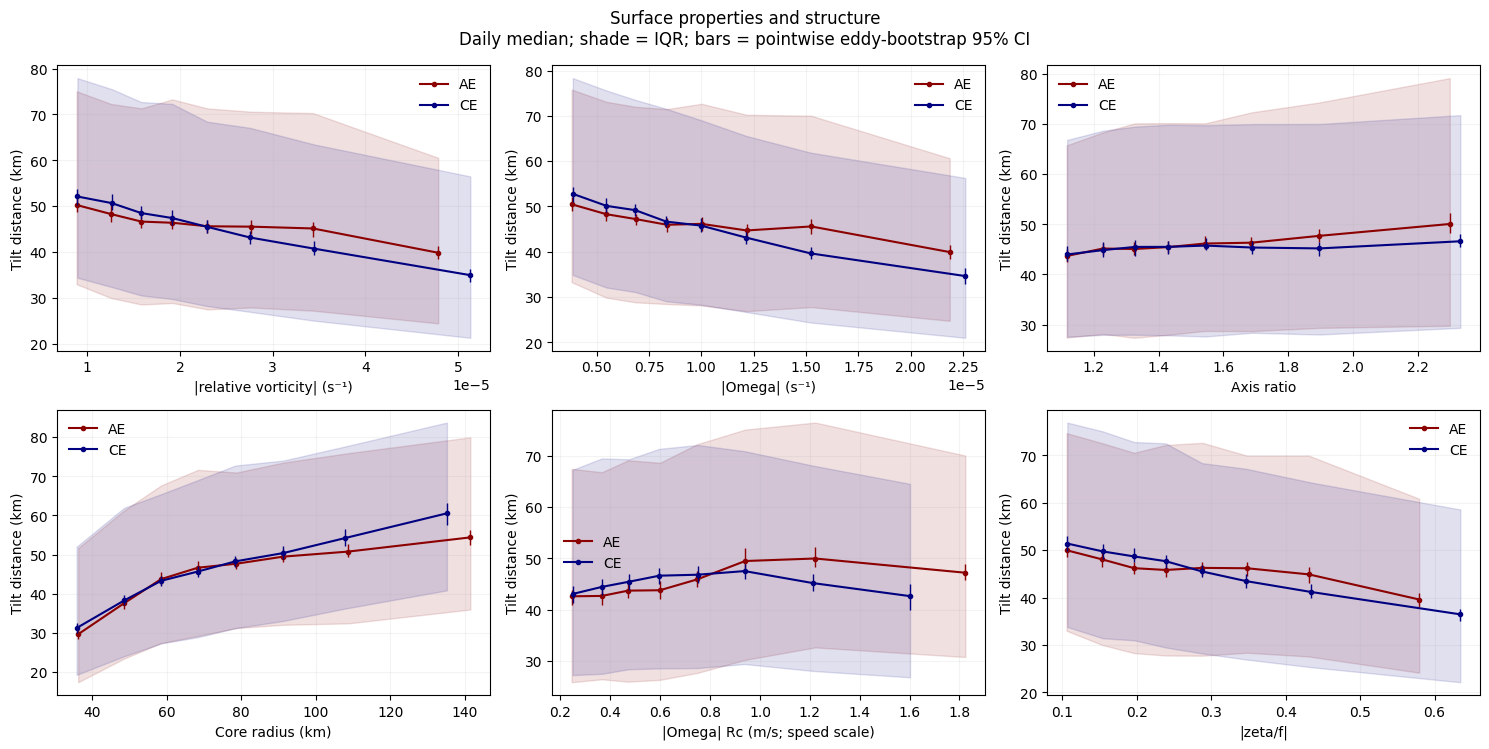

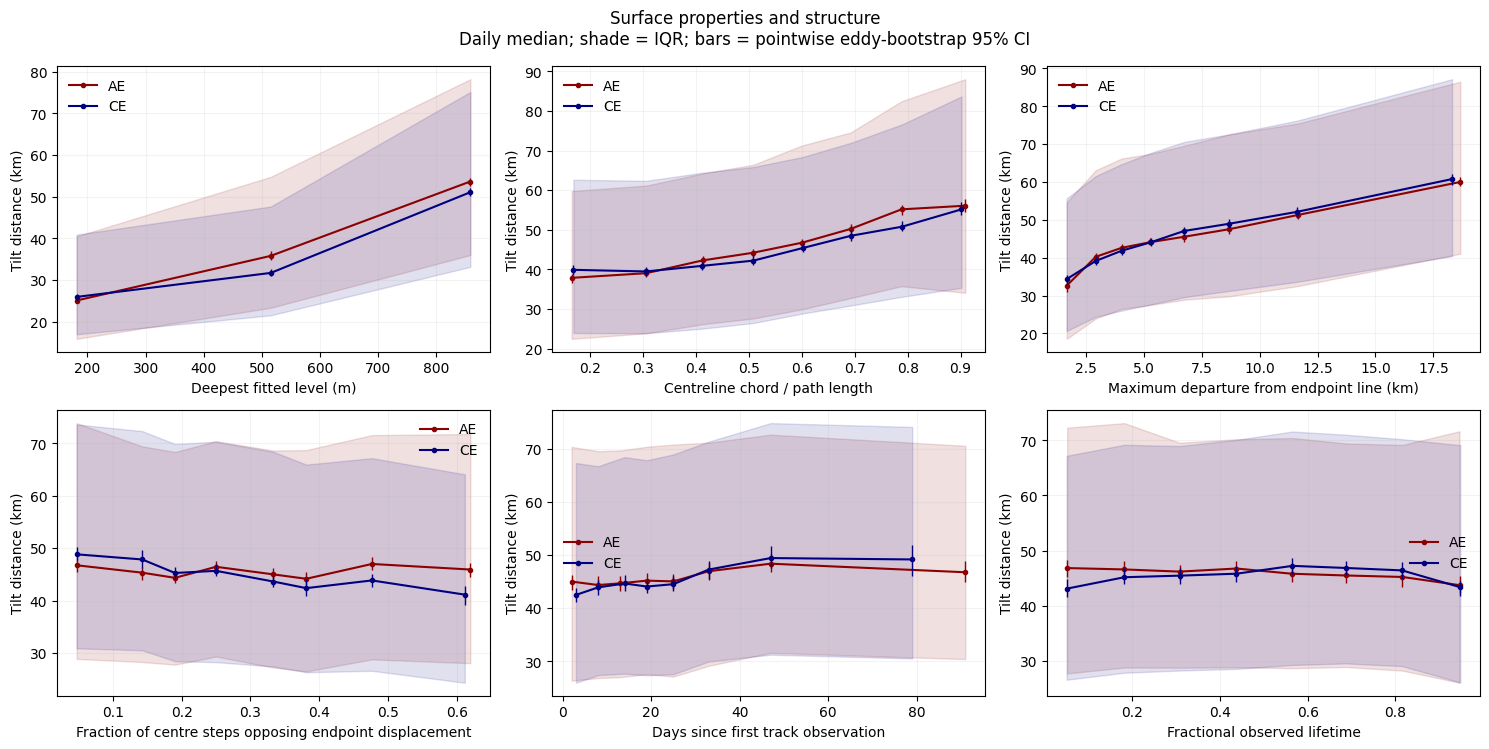

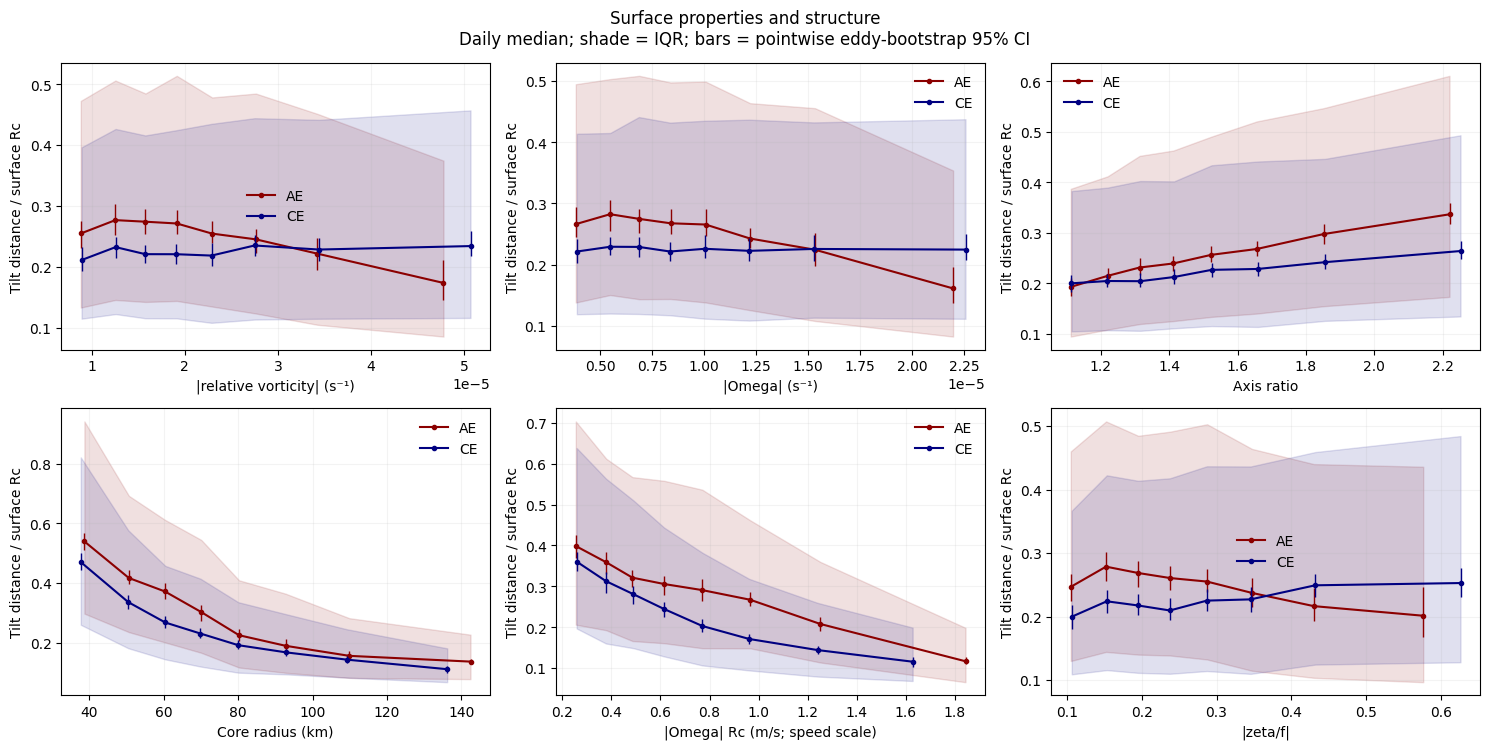

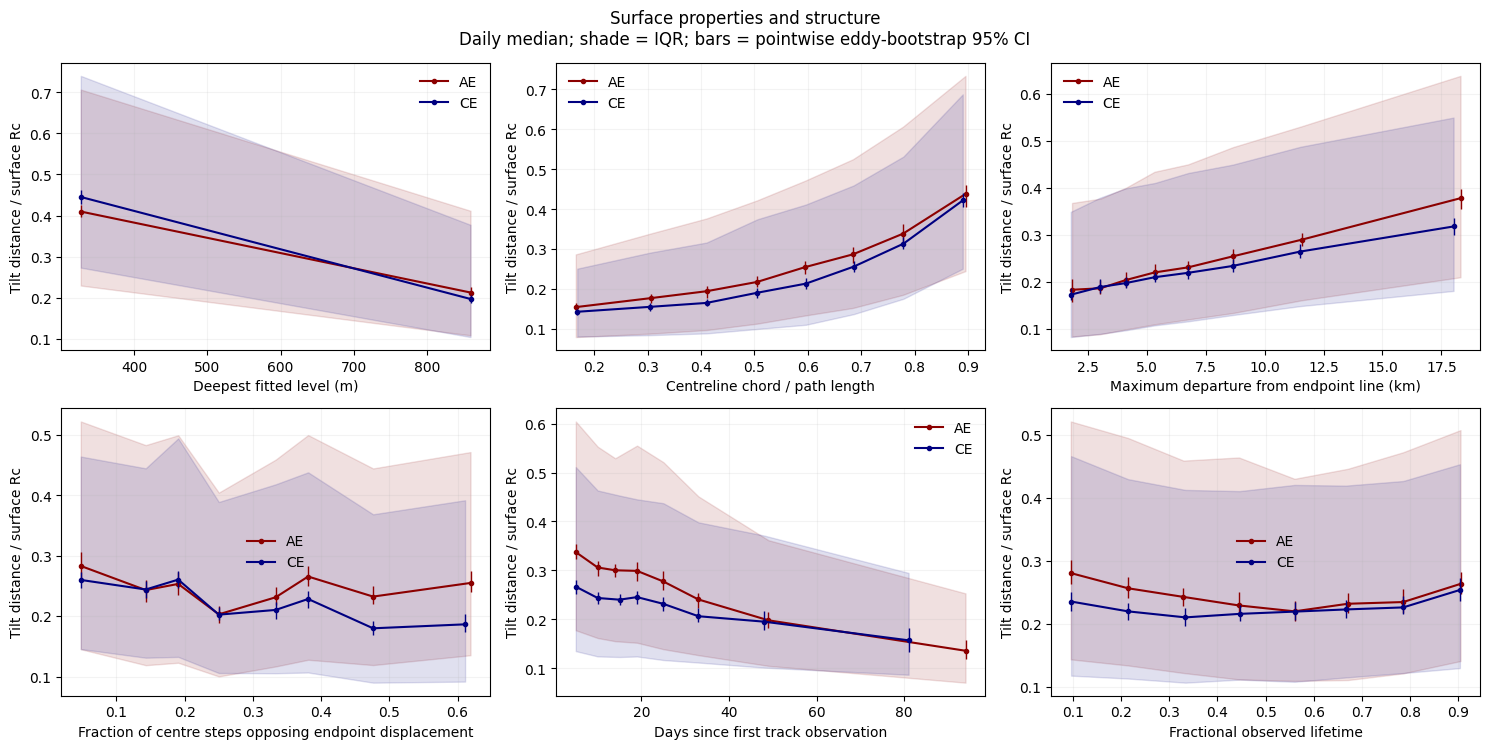

In [4]:
shape_metrics=['vertical_extent_m','profile_straightness','profile_bend_km','profile_reversal_fraction','age_days','age_fraction']
surface_metrics=ctl.PROFILE_METRICS+shape_metrics
results['surface_availability']=ctl.audit(surface,surface_metrics)
display(results['surface_availability'])
for outcome in ['TiltDis','tilt_over_radius']:
    results['surface_bins_'+outcome]=ctl.panels(surface,surface_metrics,y=outcome,n_boot=N_BOOT,min_eddies=MIN_EDDIES_PER_BIN,title='Surface properties and structure')

## Depth-dependent properties: available versus matched eddy-days
Targets resolve once to actual cached depths within the stated tolerance. There is **no interpolation or extrapolation**. Inspect the actual depths and rejected targets below. The lower row of each figure holds the Eddy-Day sample constant across all accepted depths for that property. Counts are saved by depth and polarity.

,target_m,actual_m,mismatch_m,accepted
0,0,0.000000,0.000000,True
1,100,105.615538,5.615538,True
2,200,181.264793,18.735207,True
3,500,515.416489,15.416489,True
4,1000,1128.898331,128.898331,False


KeyError: ['TiltDis']

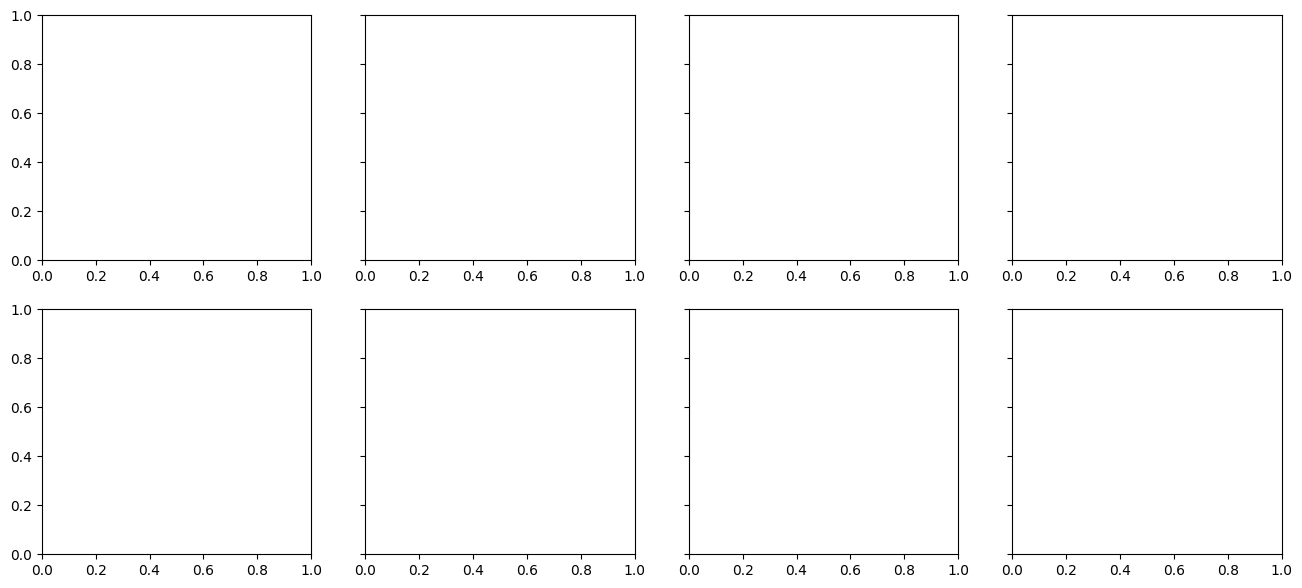

In [5]:
depth_audit=ctl.resolve_depths(vertical,TARGET_DEPTHS,DEPTH_TOLERANCE_M)
results['depth_resolution']=depth_audit
display(depth_audit)
levels=depth_audit.loc[depth_audit.accepted,'actual_m'].tolist()
if len(levels)<2: raise ValueError('Choose at least two available depth targets')
results['depth_bins'],results['depth_counts']=ctl.depth_comparison(vertical,levels,n_boot=N_BOOT,min_eddies=MIN_EDDIES_PER_BIN)
display(results['depth_counts'])

## Profile means, extrema, peak depths and vertical changes
Depth means use trapezoidal thickness weighting across all sampled levels through `MAX_DEPTH_M`, requiring finite values at every retained level. Endpoint changes are deep minus shallow. Maxima use finite levels; peak-depth ties select the shallowest. These summaries span each day's available profile, so the common-depth sensitivity below is essential.

In [ ]:
profile_metrics=[]
for suffix in ['_depth_mean','_max','_peak_depth_m','_deep_minus_shallow']:
    metrics=[m+suffix for m in ctl.PROFILE_METRICS]
    profile_metrics+=metrics
    results['profile'+suffix]=ctl.panels(surface,metrics,n_boot=N_BOOT,min_eddies=MIN_EDDIES_PER_BIN,title='Available profile: '+suffix.strip('_'))
# Common endpoints AND all intervening cached levels, with complete properties.
window=vertical.loc[vertical.Depth.between(min(levels),max(levels))].copy()
all_levels=np.sort(window.Depth.unique())
complete=ctl.finite(window,ctl.PROFILE_METRICS+['TiltDis'])
counts=complete.groupby(ctl.KEYS).Depth.nunique()
keys=counts[counts.eq(len(all_levels))].reset_index()[ctl.KEYS]
common_profiles=complete.merge(keys,on=ctl.KEYS,validate='many_to_one')
common_summary=ctl.profile_summaries(common_profiles)
common=ctl.merge(surface.drop(columns=list(set(summary)-set(ctl.KEYS))),common_summary)
print('Common-depth complete Eddy-Days:',len(keys),'range:',min(levels),max(levels))
results['common_profile_availability']=ctl.audit(common,profile_metrics)
results['common_profile_max_bins']=ctl.panels(common,[m+'_max' for m in ctl.PROFILE_METRICS],n_boot=N_BOOT,min_eddies=MIN_EDDIES_PER_BIN,title='Common-depth maxima: all intervening levels required')
results['common_profile_correlations']=ctl.correlations(common,profile_metrics,n_boot=N_BOOT)

## Corrected eddy-core stratification cache
The v4 potential-density cache contains **core**, not environmental, stratification. Each metric has its own coverage filter. Pycnocline maxima are core means of per-column vertical maxima, not the single largest value anywhere in the eddy. No retired v3 values are used. Missing caches are reported; malformed or stale caches raise an error.

In [ ]:
n2_metrics=[]
inputs.append(N2_CACHE)
if N2_CACHE.exists():
    n2=mech.load_stratification_cache(N2_CACHE)
    surface=ctl.add_n2(surface,n2,MIN_N2_COVERAGE)
    n2_metrics=ctl.N2_METRICS
    results['stratification_availability']=ctl.audit(surface,n2_metrics)
    display(results['stratification_availability'])
    results['stratification_bins']=ctl.panels(surface,n2_metrics,n_boot=N_BOOT,min_eddies=MIN_EDDIES_PER_BIN,title='Eddy-core stratification')
else:
    print('STRATIFICATION SECTION UNAVAILABLE:',N2_CACHE)
    print('Use the existing tilt_mechanisms cache builder if needed; this notebook does not rebuild caches.')

## Vertical velocity, only when the existing cache is available
Actual upward-positive water velocity is labelled `vv_*`, distinct from fitted relative vorticity `w`. Reuse the existing climatology cache at fraction 1.5, minimum 8 valid cells and 70% coverage by default. Its selected population may be a subset of all eddies; availability is reported.

Column mean and RMS weight depth rows by sampled valid-cell count. They are sample-weighted statistics, not volume fluxes or thickness-weighted column integrals. Extrema can be sensitive to isolated cells and number of samples. The deep-minus-upper core-mean difference (500–900 minus 100–300 m) is a moving-footprint screening diagnostic, not the pointwise vortex-stretching term. Positive maxima/minima are retained as signed extrema; no sign is forced.

In [ ]:
vv_metrics=[]
inputs.append(VV_CACHE)
if VV_CACHE.exists():
    vv_depth,vv_summary=ctl.vertical_velocity(pd.read_parquet(VV_CACHE),fraction=VV_FRACTION,max_depth=MAX_DEPTH_M,min_cells=MIN_VV_CELLS,min_coverage=MIN_VV_COVERAGE)
    surface=ctl.merge(surface,vv_summary)
    vv_metrics=[c for c in ['vv_mean','vv_rms','vv_max','vv_min','vv_abs_max','vv_deep_minus_upper'] if c in surface]
    results['vertical_velocity_availability']=ctl.audit(surface,vv_metrics)
    display(results['vertical_velocity_availability'])
    results['vertical_velocity_bins']=ctl.panels(surface,vv_metrics,n_boot=N_BOOT,min_eddies=MIN_EDDIES_PER_BIN,title='Cached vertical velocity')
    if len(vv_depth):
        meta=surface[ctl.KEYS+['Cyc','TiltDis']]
        vv_depth=vv_depth.drop(columns=['Cyc','TiltDis'],errors='ignore').merge(meta,on=ctl.KEYS,validate='many_to_one')
        vv_resolution=ctl.resolve_depths(vv_depth,TARGET_DEPTHS,DEPTH_TOLERANCE_M)
        results['vv_depth_resolution']=vv_resolution
        vv_levels=vv_resolution.loc[vv_resolution.accepted,'actual_m'].tolist()
        if len(vv_levels)>=2:
            results['vv_depth_bins'],results['vv_depth_counts']=ctl.depth_comparison(vv_depth,vv_levels,metrics=['vv_mean','vv_rms','vv_abs_max'],n_boot=N_BOOT,min_eddies=MIN_EDDIES_PER_BIN)
else:
    print('VERTICAL VELOCITY SECTION UNAVAILABLE:',VV_CACHE)
    print('Existing builder: vertical_velocity/02_vertical_velocity_climatology.ipynb. No new builder is created or run.')

## Equal-eddy sensitivity and adjusted associations
Review coverage before reading coefficients. The model tables explicitly report skipped or rank-deficient comparisons. No inference treats repeated eddy-days as independent replicates.

In [ ]:
all_metrics=surface_metrics+profile_metrics+n2_metrics+vv_metrics
for outcome in ['TiltDis','tilt_over_radius']:
    results['eddy_equal_correlations_'+outcome]=ctl.correlations(surface,all_metrics,y=outcome,n_boot=N_BOOT)
    results['adjusted_'+outcome]=ctl.adjusted(surface,all_metrics,y=outcome)
    display(results['eddy_equal_correlations_'+outcome])
    display(results['adjusted_'+outcome])

## Export tables and settings
Each run saves to a new UTC-stamped subfolder, preventing results from missing cache sections being mixed with older runs. Source paths, sizes and timestamps are recorded; these are not full data checksums.

In [ ]:
NOTEBOOK_NAME='eddy_properties'

if SAVE_RESULTS:
    settings=dict(n_boot=N_BOOT,min_eddies_per_bin=MIN_EDDIES_PER_BIN,max_depth_m=MAX_DEPTH_M,
                  target_depths=TARGET_DEPTHS,depth_tolerance_m=DEPTH_TOLERANCE_M,
                  n2_min_coverage=MIN_N2_COVERAGE,vv_fraction=VV_FRACTION,
                  vv_min_cells=MIN_VV_CELLS,vv_min_coverage=MIN_VV_COVERAGE,
                  unavailable_sections=[str(p) for p in inputs if not Path(p).exists()])
    saved=ctl.save_results(OUTPUT_ROOT/NOTEBOOK_NAME,results,settings,inputs)
    print('Saved tables and provenance to',saved)